# CA2 - Training

The classes I am using for this assessment are a **laundry basket** and a **showerhead**. I am using these because they are everyday objects that are not included in the IMAGENET 1000 Class List. This will be useful for transfer learning later on.

Because I have two classes, this is a **binary classification** problem.

I have collected 300 JPEG images of each class and cleaned them by manually removing images that are not good examples of the class and stripping the images of their exif data using Exiftool. I then partitioned the images into a training set containing 120 images of each class, a validation set containing 90 images of each class, and a test set also containing 90 images of each class.

## Setting Things Up

In [ ]:
import matplotlib.pyplot as plt

! pip install keras_tuner
import keras_tuner

from keras.preprocessing import image_dataset_from_directory
from keras import Model
from keras import Input

from keras.layers import Dense
from keras.layers import Rescaling
from keras.layers import Flatten
from keras.layers import Conv2D
from keras.layers import MaxPooling2D
from keras.layers import BatchNormalization
from keras.layers import Dropout

from keras.optimizers import RMSprop

from keras.layers import RandomFlip
from keras.layers import RandomRotation
from keras.layers import RandomZoom
from keras.layers import RandomTranslation

from keras.applications import ResNet50
import keras.applications.resnet as resnet

In [ ]:
#Find the epoch at which validation loss was lowest and print its accuracy, val accuracy and val loss
def best_metrics(hist):
  idx = None
  min_loss = float("inf")
  for i in range(len(hist.history["val_loss"])):
    if hist.history["val_loss"][i] < min_loss:
      min_loss = hist.history["val_loss"][i]
      idx = i
  print("Best epoch:")
  print("Accuracy:", hist.history["accuracy"][idx])
  print("Validation accuracy:", hist.history["val_accuracy"][idx])
  print("Validation loss:", hist.history["val_loss"][idx])

In [ ]:
def plot_keras_history(history, metric):
    fig, axes = plt.subplots(1, 2, figsize=(6, 3))
    fig.tight_layout()
    axes[0].plot(history.history["loss"], label="train loss")
    axes[0].plot(history.history["val_loss"], label="val loss")
    axes[0].set_title("Loss")
    axes[0].legend()
    axes[1].plot(history.history[metric], label="train " + metric)
    axes[1].plot(history.history["val_" + metric], label="val " + metric)
    axes[1].set_title(metric)
    axes[1].legend()
    plt.show()

## Reading in the Images

In [ ]:
import os
from google.colab import drive
drive.mount('/content/drive')
base_dir = "./drive/My Drive/Colab Notebooks/ca2"     #Edit this as necessary
train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "val")
test_dir = os.path.join(base_dir, "test")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


I will use the `image_dataset_from_directory` function in Keras to read in the images.

Since I have two classes, the `label_mode` should be `binary` so that the classes will be encoded as 0 and 1. The labels will be inferred from the directory structure by default.

To be used as inputs in a neural network, the images must all be of the same size, so they will have to be resized. I will use `(256, 256)` for `image_size`. This is the same as the default value, but I will state it explicitly.

The default value for `color_mode` is `"rgb"`, which is appropriate for these colour images.

I will use the default values for each of the other parameters.

In [ ]:
train_dataset = image_dataset_from_directory(directory=train_dir, label_mode="binary", image_size=(256, 256))
val_dataset = image_dataset_from_directory(directory=val_dir, label_mode="binary", image_size=(256, 256))
test_dataset = image_dataset_from_directory(directory=test_dir, label_mode="binary", image_size=(256, 256))

Found 240 files belonging to 2 classes.
Found 180 files belonging to 2 classes.
Found 180 files belonging to 2 classes.


# Training Models

I will now begin training some networks.

I will not flatten the images, as I don't want to lose data such as which pixels are next to each other. These colour images will have a height and width of 256 and 3 values for colour (RGB), so in each of my models, the input will be a rank 3 tensor of shape `(256, 256, 3)`.

Standardizing using a `Normalization` layer is not necessary here as each colour value will be in the range [0, 255], but since it is best practice to not feed in values to the network that are much larger than the initial weights, I will divide the values by 255 to scale them down to the range [0, 1].

Since this is binary classification,  the output layer will consist of a single neuron using the sigmoid activation function. It will output the probability of the image being a showerhead

As this is a classification problem, I will use **accuracy** as the performance metric, and since there are two classes, I will use **binary cross-entropy** as the loss function.

## Convolutional Neural Networks

I will focus on convolutional neural networks for this task, as they have several properties that make them particularly suitable for computer vision problems such as this. For example:

- The features they learn are **translation invariant**, meaning a feature map in a convolutional layer can recognise the feature regardless of where it appears in the image.
- They can learn **spatial hierarchies** of features. The lower layers can learn to recognise small features in the image, while higher layers can spot larger features.

In each of these networks, I will include a dense layer below the output to combine the features discovered by the lower layers and perform the final classification. Since this layer will expect a 1D array of features, the outputs of the previous layers must be flattened.

For the remaining hidden layers, I will use a fairly typical structure for a CNN. In addition to 2D convolutional layers (with a fairly standard kernel size of 3x3), I will include max pooling layers to reduce the number of neurons in the higher layers of the network. I will use the typical pool size of 2x2.

This has the benefit of reducing the amount of computation, reducing the number of parameters, and, particularly important for this task, creating a hierarchy of information so that higher layers contain information about the totality of the original input image.

The activation function for the hidden layers can be sigmoid or ReLU, however, sigmoid is rarely used in networks such as these with several hidden layers since it is more susceptible to the vanishing gradient problem. For now, I will use ReLU for the hidden layers in this network.

I will use the `RMSprop` optimizer with a learning rate of 0.001.

To start, I will build a model with a configuration based on examples from the course materials.

- I will include a 2D convolutional layer, followed by a max pooling layer, then repeat this several times (3 times to begin with).
- The number of filters used in the `Conv2D` layers will begin at 256 and will be halfed at each repetition, going no lower than 32.

Later, I will fine tune some of the parameters I am using and consider other techniques.

In [ ]:
inputs = Input(shape=(256, 256, 3))
x = Rescaling(scale=1./255)(inputs)

f = 256
for _ in range(3):
  x = Conv2D(filters=f, kernel_size=(3, 3), activation="relu")(x)
  x = MaxPooling2D(pool_size=(2, 2))(x)
  if f > 32:
    f = f // 2

x = Flatten()(x)
x = Dense(units=512, activation="relu")(x)
outputs = Dense(units=1, activation="sigmoid")(x)
convnet1 = Model(inputs, outputs)

In [ ]:
convnet1.compile(optimizer=RMSprop(learning_rate=0.001), loss="binary_crossentropy", metrics=["accuracy"])

In [ ]:
convnet1.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 256)  │         7,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 256)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 128)  │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    29,491,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,868,225 (113.94 MB)

 Trainable params: 29,868,225 (113.94 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
convnet1_history = convnet1.fit(train_dataset, epochs=30, validation_data=val_dataset, verbose=0)

In [ ]:
print(convnet1_history.history["accuracy"])
print(convnet1_history.history["val_accuracy"])
print(convnet1_history.history["val_loss"])

[0.5583333373069763, 0.5, 0.46666666865348816, 0.6625000238418579, 0.5625, 0.5791666507720947, 0.6041666865348816, 0.637499988079071, 0.6208333373069763, 0.625, 0.6291666626930237, 0.550000011920929, 0.6875, 0.7791666388511658, 0.7583333253860474, 0.7708333134651184, 0.7458333373069763, 0.8500000238418579, 0.762499988079071, 0.8291666507720947, 0.6708333492279053, 0.8291666507720947, 0.875, 0.7958333492279053, 0.8208333253860474, 0.8708333373069763, 0.8833333253860474, 0.7250000238418579, 0.8916666507720947, 0.9083333611488342]
[0.5, 0.5, 0.7611111402511597, 0.5, 0.5444444417953491, 0.5333333611488342, 0.5333333611488342, 0.5444444417953491, 0.7444444298744202, 0.7777777910232544, 0.5833333134651184, 0.5055555701255798, 0.5222222208976746, 0.5944444537162781, 0.7166666388511658, 0.6777777671813965, 0.8222222328186035, 0.6388888955116272, 0.8388888835906982, 0.7555555701255798, 0.8222222328186035, 0.8277778029441833, 0.7944444417953491, 0.800000011920929, 0.8444444537162781, 0.855555534



```
[0.46666666865348816, 0.5291666388511658, 0.550000011920929, 0.5708333253860474, 0.5916666388511658, 0.6625000238418579, 0.5958333611488342, 0.6291666626930237, 0.5791666507720947, 0.5833333134651184, 0.6041666865348816, 0.75, 0.5958333611488342, 0.7083333134651184, 0.7291666865348816, 0.8041666746139526, 0.7708333134651184, 0.8041666746139526, 0.7458333373069763, 0.8208333253860474, 0.6291666626930237, 0.7666666507720947, 0.8333333134651184, 0.7875000238418579, 0.7041666507720947, 0.8374999761581421, 0.9041666388511658, 0.6291666626930237, 0.862500011920929, 0.8958333134651184]
[0.5277777910232544, 0.5166666507720947, 0.5, 0.75, 0.5, 0.5, 0.5722222328186035, 0.7555555701255798, 0.6000000238418579, 0.550000011920929, 0.8500000238418579, 0.8388888835906982, 0.5, 0.5222222208976746, 0.7777777910232544, 0.5, 0.800000011920929, 0.5055555701255798, 0.8500000238418579, 0.5, 0.5277777910232544, 0.800000011920929, 0.800000011920929, 0.7833333611488342, 0.8611111044883728, 0.7833333611488342, 0.6611111164093018, 0.7833333611488342, 0.8277778029441833, 0.6499999761581421]
[0.6904404759407043, 0.6916786432266235, 0.685872495174408, 0.674409806728363, 0.7316814661026001, 0.707672655582428, 0.6634306311607361, 0.5575268864631653, 0.6660254001617432, 0.6740469336509705, 0.6031404137611389, 0.45657098293304443, 0.591515839099884, 0.8620291948318481, 0.444783091545105, 0.9612072706222534, 0.45455241203308105, 0.87744140625, 0.37264424562454224, 0.9356819987297058, 0.6646581888198853, 0.46053075790405273, 0.5257001519203186, 0.47286897897720337, 0.4472047686576843, 0.5228167772293091, 0.7127916216850281, 0.4958783984184265, 0.41327720880508423, 0.662697970867157]
```



In [ ]:
best_metrics(convnet1_history)

Best model:
Accuracy: 0.8708333373069763
Validation accuracy: 0.855555534362793
Validation loss: 0.3622381091117859


```
Best model:
Accuracy: 0.8708333373069763
Validation accuracy: 0.855555534362793
Validation loss: 0.3622381091117859
```

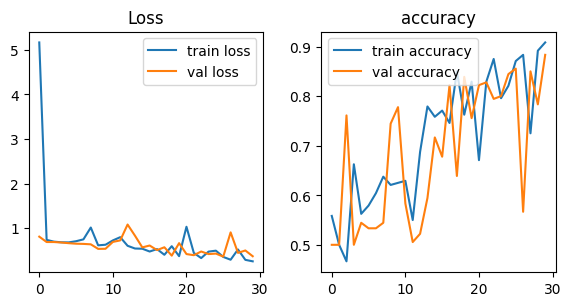

In [ ]:
plot_keras_history(convnet1_history, "accuracy")

The accuracy figures for the model with the least loss are decent but not great, and the highly erratic nature of the training and validation accuracies suggests these numbers should be taken with a heap of salt.

## Tuning hyperparameters

My initial model did not produce very impressive results. There are many different techniques that could be tried to improve it, but first I feel it is best to try to tune some of the parameters used to build the model.

- **Number of repetitions**: This is the number of times a convolutional layer and max pooling layer are added to the network. It appears that the previous model was somewhat underfitting most of the time, so it may make sense to add more layers and increase the complexity of the network.
- I will try some different options for the **hidden layer  activation functions** and **convolutional layer intializers**. As discussed above, ReLU is likely the best choice for the activation function, but I feel it is worth trying a few different combinations.
- One new tehcnique I will try is **batch normalization**. Among other benefits, this may help prevent overfitting as the complexity of the network is increased.

There are several other parameters that could be adjusted, but I will go with these for now.

I will perform a random search to test some combinations of these options.

In [ ]:
# def build_convnet(hp):
#   hp_n_repetitions = hp.Choice("n_repetitions", range(3, 7))
#   hp_activation = hp.Choice("activation", ["sigmoid", "relu"])
#   hp_initialization = hp.Choice("initialization", ["random_normal", "glorot_uniform"])
#   hp_is_batch_normalized = hp.Boolean("is_batch_normalized")

#   inputs = Input(shape=(256, 256, 3))
#   x = Rescaling(scale=1./255)(inputs)

#   f = 256
#   for _ in range(hp_n_repetitions):
#     x = Conv2D(filters=f, kernel_size=(3, 3), activation=hp_activation, kernel_initializer=hp_initialization)(x)
#     if hp_is_batch_normalized:
#       x = BatchNormalization()(x)
#     x = MaxPooling2D(pool_size=(2, 2))(x)
#     if f > 32:
#       f = f // 2

#   x = Flatten()(x)
#   x = Dense(units=512, activation=hp_activation)(x)
#   outputs = Dense(units=1, activation="sigmoid")(x)
#   model = Model(inputs, outputs)

#   model.compile(optimizer=RMSprop(learning_rate=0.001), loss="binary_crossentropy", metrics=["accuracy"])

#   return model

In [ ]:
# tuner = keras_tuner.RandomSearch(
#     build_convnet,
#     objective="val_accuracy",
#     directory = base_dir,
#     project_name = "tuner_state",
#     overwrite=True
# )

In [ ]:
# tuner.search(train_dataset, epochs=10, validation_data=val_dataset)

In [ ]:
# tuner.get_best_hyperparameters()[0].values

```
{'n_repetitions': 5,
 'activation': 'relu',
 'initialization': 'random_normal',
 'is_batch_normalized': True}
```

The search found increasing the network's complexity to be beneficial and stuck with ReLU for the activation function, which were to be expected. It also chose to use the random normal initializer and include batch normalization.

I will now build a new model based on these results.

In [ ]:
inputs = Input(shape=(256, 256, 3))
x = Rescaling(scale=1./255)(inputs)

f = 256
for _ in range(5):
  x = Conv2D(filters=f, kernel_size=(3, 3), activation="relu", kernel_initializer="random_normal")(x)
  x = BatchNormalization()(x)
  x = MaxPooling2D(pool_size=(2, 2))(x)
  if f > 32:
    f = f // 2

x = Flatten()(x)
x = Dense(units=512, activation="relu")(x)
outputs = Dense(units=1, activation="sigmoid")(x)
best_search_model = Model(inputs, outputs)

In [ ]:
best_search_model.compile(optimizer=RMSprop(learning_rate=0.001), loss="binary_crossentropy", metrics=["accuracy"])

In [ ]:
best_search_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 254, 254, 256)  │         7,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 256)  │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 127, 127, 256)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 125, 125, 128)  │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 62, 62, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 60, 60, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       590,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 996,609 (3.80 MB)

 Trainable params: 995,585 (3.80 MB)

 Non-trainable params: 1,024 (4.00 KB)

In [ ]:
best_search_model_history = best_search_model.fit(train_dataset, epochs=30, validation_data=val_dataset, verbose=0)

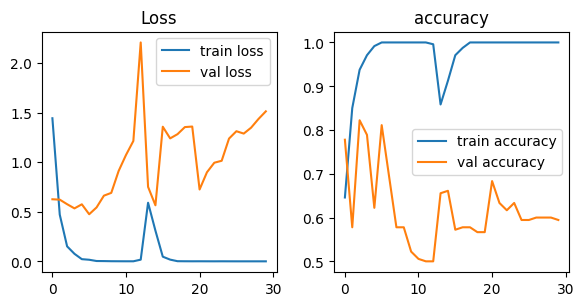

In [ ]:
plot_keras_history(best_search_model_history, "accuracy")

In [ ]:
best_metrics(best_search_model_history)

Best model:
Accuracy: 1.0
Validation accuracy: 0.8111110925674438
Validation loss: 0.47465193271636963


```
Best model:
Accuracy: 1.0
Validation accuracy: 0.8111110925674438
Validation loss: 0.47465193271636963
```

This model is clearly overfitting, with a training accuracy of 100% and OK validation accuracy of 81%.

## Dropout

I feel the best course of action for now is to try to improve the overfitting second model, since the first model was very erratic, and there are several techniques for reducing overfitting in neural networks.

Weight regularization could be used, but it is most useful in small networks. There are many possible choices here, but for now I will try **dropout**.

I will run another random search to decide whether to use dropout and what rate to use. I will also include the number of repetitions in the search again, since dropout could affect the optimal choice for complexity. To make the search a bit more comprehensive, I will run a few more trials this time.

In [ ]:
# def build_dropout_convnet(hp):
#   hp_n_repetitions = hp.Choice("n_repetitions", range(3, 7))
#   hp_dropout_rate = hp.Choice("dropout", [0.0, 0.2, 0.3, 0.4, 0.5])    #0 for no dropout

#   inputs = Input(shape=(256, 256, 3))
#   x = Rescaling(scale=1./255)(inputs)

#   f = 256
#   for _ in range(hp_n_repetitions):
#     x = Conv2D(filters=f, kernel_size=(3, 3), activation="relu", kernel_initializer="random_normal")(x)
#     x = BatchNormalization()(x)
#     x = MaxPooling2D(pool_size=(2, 2))(x)
#     if hp_dropout_rate > 0:
#       x = Dropout(rate=hp_dropout_rate)(x)
#     if f > 32:
#       f = f // 2

#   x = Flatten()(x)
#   x = Dense(units=512, activation="relu")(x)
#   outputs = Dense(units=1, activation="sigmoid")(x)
#   model = Model(inputs, outputs)

#   model.compile(optimizer=RMSprop(learning_rate=0.001), loss="binary_crossentropy", metrics=["accuracy"])

#   return model

In [ ]:
# tuner_dropout = keras_tuner.RandomSearch(
#     build_dropout_convnet,
#     objective="val_accuracy",
#     directory = base_dir,
#     project_name = "tuner_state",
#     overwrite=True,
#     max_trials=15
# )

In [ ]:
# tuner_dropout.search(train_dataset, epochs=10, validation_data=val_dataset)

In [ ]:
# tuner_dropout.get_best_hyperparameters()[0].values

```
{'n_repetitions': 6, 'dropout': 0.2}
```

The search decided upon a slightly more complex network and found dropout to be beneficial, with a rate of 0.2.

In [ ]:
inputs = Input(shape=(256, 256, 3))
x = Rescaling(scale=1./255)(inputs)

f = 256
for _ in range(6):
  x = Conv2D(filters=f, kernel_size=(3, 3), activation="relu", kernel_initializer="random_normal")(x)
  x = BatchNormalization()(x)
  x = MaxPooling2D(pool_size=(2, 2))(x)
  x = Dropout(rate=0.2)(x)
  if f > 32:
    f = f // 2

x = Flatten()(x)
x = Dense(units=512, activation="relu")(x)
outputs = Dense(units=1, activation="sigmoid")(x)
best_dropout_model = Model(inputs, outputs)

In [ ]:
best_dropout_model.compile(optimizer=RMSprop(learning_rate=0.001), loss="binary_crossentropy", metrics=["accuracy"])

In [ ]:
best_dropout_model_history = best_dropout_model.fit(train_dataset, epochs=30, validation_data=val_dataset, verbose=0)

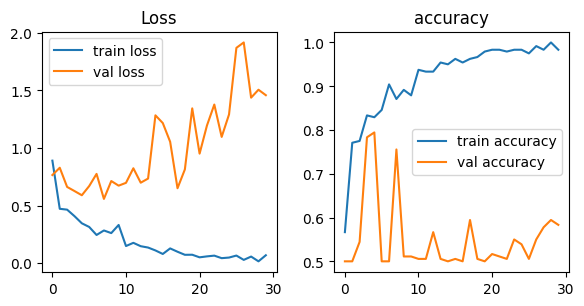

In [ ]:
plot_keras_history(best_dropout_model_history, "accuracy")

In [ ]:
best_metrics(best_dropout_model_history)

Best model:
Accuracy: 0.8708333373069763
Validation accuracy: 0.7555555701255798
Validation loss: 0.557384729385376


```
Best model:
Accuracy: 0.8708333373069763
Validation accuracy: 0.7555555701255798
Validation loss: 0.557384729385376
```

The gap between the training and validation accuracies has narrowed, but the validation accuracy has actually gone down. Looking at the graph, I can see it never exceeded 80%.

## Data Augmentation

I could try adjusting the model with dropout, but, based on the previous results, it doesn't seem like dropout alone is going to be hugely successful.

I will now a try different approach of data augmentation, which is commonly used to reduce overfitting. I will add new artifical data by applying random transformations to the training images (flipping, rotating, zooming and translation). To ensure the images remain recognisable, I will not perform vertical flips or change the aspect ratio.

To add an extra degree of variation, the factors for the rotations, zooms and translations will be random values in the range `(-0.2, 0.2)`.

If this proves successful, I may try combining it with dropout and other techniques.

In [ ]:
inputs = Input(shape=(256, 256, 3))
x = RandomFlip(mode="horizontal")(inputs)
x = RandomRotation(factor=(-0.2, 0.2))(x)
x = RandomZoom(height_factor=(-0.2, 0.2))(x)
x = RandomTranslation(height_factor=(-0.2, 0.2), width_factor=(-0.2, 0.2))(x)
x = Rescaling(scale=1./255)(x)

f = 256
for _ in range(6):
  x = Conv2D(filters=f, kernel_size=(3, 3), activation="relu", kernel_initializer="random_normal")(x)
  x = BatchNormalization()(x)
  x = MaxPooling2D(pool_size=(2, 2))(x)
  x = Dropout(rate=0.2)(x)
  if f > 32:
    f = f // 2

x = Flatten()(x)
x = Dense(units=512, activation="relu")(x)
outputs = Dense(units=1, activation="sigmoid")(x)
data_aug_model = Model(inputs, outputs)

In [ ]:
data_aug_model.compile(optimizer=RMSprop(learning_rate=0.001), loss="binary_crossentropy", metrics=["accuracy"])

In [ ]:
data_aug_model_history = data_aug_model.fit(train_dataset, epochs=30, validation_data=val_dataset, verbose=0)

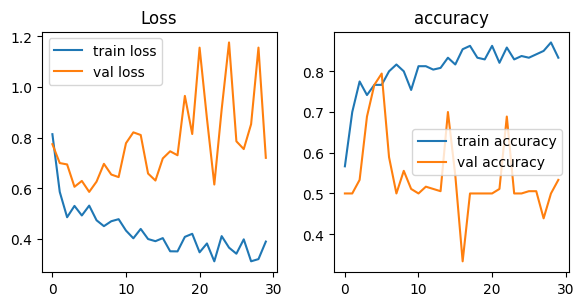

In [ ]:
plot_keras_history(data_aug_model_history, "accuracy")

In [ ]:
best_metrics(data_aug_model_history)

Best model:
Accuracy: 0.7666666507720947
Validation accuracy: 0.7944444417953491
Validation loss: 0.5858983993530273


```
Best model:
Accuracy: 0.7666666507720947
Validation accuracy: 0.7944444417953491
Validation loss: 0.5858983993530273
```

There has been some improvement in validation accuracy, but this does not seem to have been very successful either.

## Transfer Learning

There are many other things I could try to improve the previous models, such as trying different configurations and tuning other parameters such as the optimizers and learning rates, but it still seems like all of the models I have built are quite far from a good solution.

A possible reason for this is the size of my dataset - I am only using 120 images of each class for training. It is likely difficult for the model to learn sufficient image recognition features with such a small amount of training data.

In accordance with the assessment instructions, I cannot collect additional training examples. The only other practical solution is to use **transfer learning**.

The first model I will try for this is ResNet50, which should be suitable since it is a deep convolutional network trained on the ImageNet dataset. Laundry baskets and showerheads are not one of the classes for this dataset, but they are both everyday objects, so it is likely that some of the features learned by ResNet50 will be useful for this task.

In [ ]:
resnet50_base = ResNet50(weights="imagenet", include_top=False, input_shape=(256, 256, 3))

I will use the same architecture as before for the inputs and higher layers, but with ResNet50 in place of most of the previous hidden layers.

In [ ]:
inputs = Input(shape=(256, 256, 3))
x = resnet.preprocess_input(inputs)
x = resnet50_base(x)
x = Flatten()(x)
x = Dense(units=512, activation="relu")(x)
outputs = Dense(units=1, activation="sigmoid")(x)
rn50_transfer_model = Model(inputs, outputs)

For the moment, I will not retrain the layers of ResNet50. I may consider it in the next stage if the model still needs to be improved.

In [ ]:
for layer in resnet50_base.layers:
    layer.trainable = False

In [ ]:
rn50_transfer_model.compile(optimizer=RMSprop(learning_rate=0.001), loss="binary_crossentropy", metrics=["accuracy"])

In [ ]:
rn50_transfer_model_history = rn50_transfer_model.fit(train_dataset, epochs=30, validation_data=val_dataset, verbose=0)

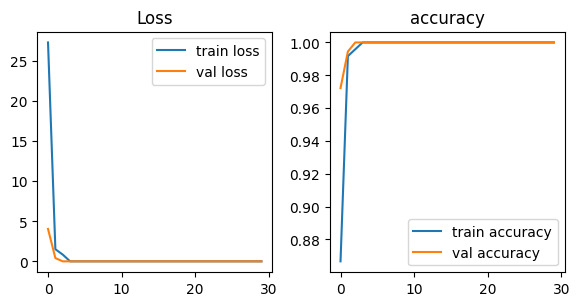

In [ ]:
plot_keras_history(rn50_transfer_model_history, "accuracy")

In [ ]:
best_metrics(rn50_transfer_model_history)

Best model:
Accuracy: 0.9958333373069763
Validation accuracy: 1.0
Validation loss: 0.0


```
Best model:
Accuracy: 0.9958333373069763
Validation accuracy: 1.0
Validation loss: 0.0
```

In [ ]:
rn50_transfer_model_history.history["accuracy"]

[0.8666666746139526,
 0.9916666746139526,
 0.9958333373069763,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0]

In [ ]:
rn50_transfer_model_history.history["val_accuracy"]

[0.9722222089767456,
 0.9944444298744202,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0]

In [ ]:
rn50_transfer_model_history.history["val_loss"]

[4.030326843261719,
 0.405110627412796,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0]

We appear to have a winner. The model has perfect validation accuracy, and there is no erraticism.

Of course, an accuracy of 100% should be treated with some suspicion, but since there are no obvious issues, I am happy to choose this as my final model. I will examine it further here (by performing error estimation) and in the demo notebook.

Given these results, I don't believe there would be much point in trying to improve this model further. If there was still room for improvement, I would have next tried retraining the base layers of ResNet50, tuning other parameters such as the optimizer and learning rate, making adjustments to the model architecture (such as the number of units in the dense layer), and possibly performing transfer learning with other base models.

## Other Considerations

There are two other notable things that I did not try in my model selection:

Even though it is often effective against overfitting, I did not use **early stopping** since I wanted to examine the full accuracy and loss history of each of the models I tried. The earlier models would  have been unsatisfactory regardless of whether early stopping was used.

In the case of this model, the lowest validation loss was achieved after just 3 epochs, so early stopping could have been used here. The loss and accuracy did not degrade, so there is no need to refit using early stopping.

For the same reasons, there was no need to reduce the number of epochs.

I could have tried **increasing the number of epochs**, but I don't believe this would have been of much benefit either. Each of my models had either become erratic, begun to overfit or achieved perfect accuracy after 30 epochs, so there was no reason to think there would have been any signficiant improvement in further epochs.


## Error Estimation

I will now estimate the error of my model on unseen data based by evaluating it on the test set.

In [ ]:
test_loss, test_acc = rn50_transfer_model.evaluate(test_dataset)
test_acc

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - accuracy: 1.0000 - loss: 0.0000e+00


1.0

The model achieves 100% accuracy even on the test set.

It appears that, with there being only two classes, the classes of images are distinct enough that it is not difficult to separate them using the features learned by ResNet50.

## Saving the Network

In [ ]:
rn50_transfer_model.save(os.path.join(base_dir, "best_network.keras"))